In [29]:
pip install uproot awkward matplotlib

Note: you may need to restart the kernel to use updated packages.


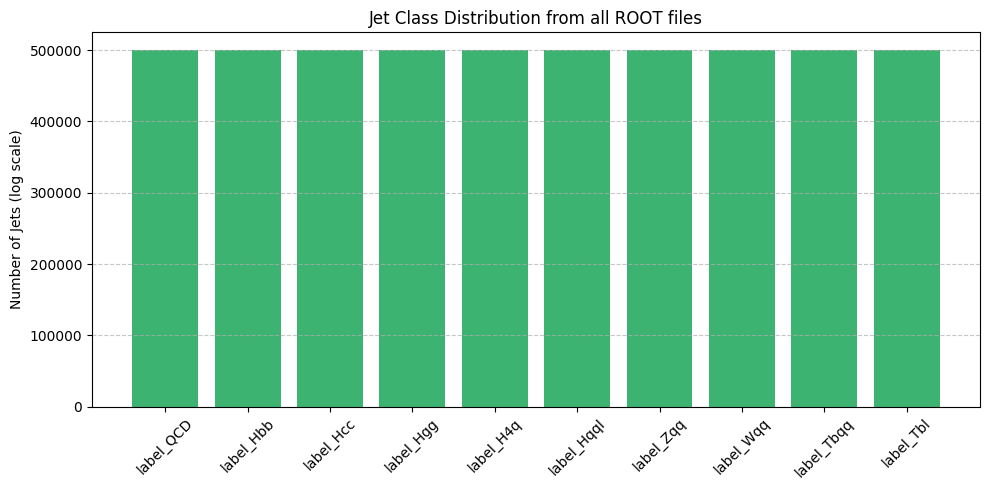

In [30]:
import uproot
import awkward as ak
import os

# Set path to your val_5M dataset
path = "val_5M"
label_fields = [
    "label_QCD", "label_Hbb", "label_Hcc", "label_Hgg", "label_H4q",
    "label_Hqql", "label_Zqq", "label_Wqq", "label_Tbqq", "label_Tbl"
]

total_counts = dict.fromkeys(label_fields, 0)

for fname in os.listdir(path):
    if not fname.endswith(".root"):
        continue
    with uproot.open(os.path.join(path, fname)) as file:
        tree = file["tree"]
        available = [label for label in label_fields if label in tree.keys()]
        arrays = tree.arrays(available)
        for label in available:
            total_counts[label] += ak.to_numpy(arrays[label]).sum()

# Now plot
import matplotlib.pyplot as plt

labels = list(total_counts.keys())
values = list(total_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="mediumseagreen")
#plt.yscale("log")
plt.xticks(rotation=45)
plt.ylabel("Number of Jets (log scale)")
plt.title("Jet Class Distribution from all ROOT files")
plt.grid(axis="y", which="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [31]:
pip install awkward

Note: you may need to restart the kernel to use updated packages.


In [32]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# ✅ Correct field check
if all(field in arrays.fields for field in ["part_deta", "part_dphi", "part_px", "part_py"]):
    deta = ak.to_numpy(ak.flatten(arrays["part_deta"]))
    dphi = ak.to_numpy(ak.flatten(arrays["part_dphi"]))
    px = ak.to_numpy(ak.flatten(arrays["part_px"]))
    py = ak.to_numpy(ak.flatten(arrays["part_py"]))
    pt = np.sqrt(px**2 + py**2)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    p = ax.scatter(deta, dphi, pt, c=pt, cmap="plasma", s=4)
    fig.colorbar(p, ax=ax, label=r"Constituent $p_T$ [GeV]")

    ax.set_xlabel(r"$\Delta\eta$")
    ax.set_ylabel(r"$\Delta\phi$")
    ax.set_zlabel(r"$p_T$ [GeV]")
    ax.set_title("Jet Constituent Cloud: Δη vs Δφ vs $p_T$")
    plt.tight_layout()
    plt.show()
else:
    print("One or more required fields are missing from the arrays.")


One or more required fields are missing from the arrays.


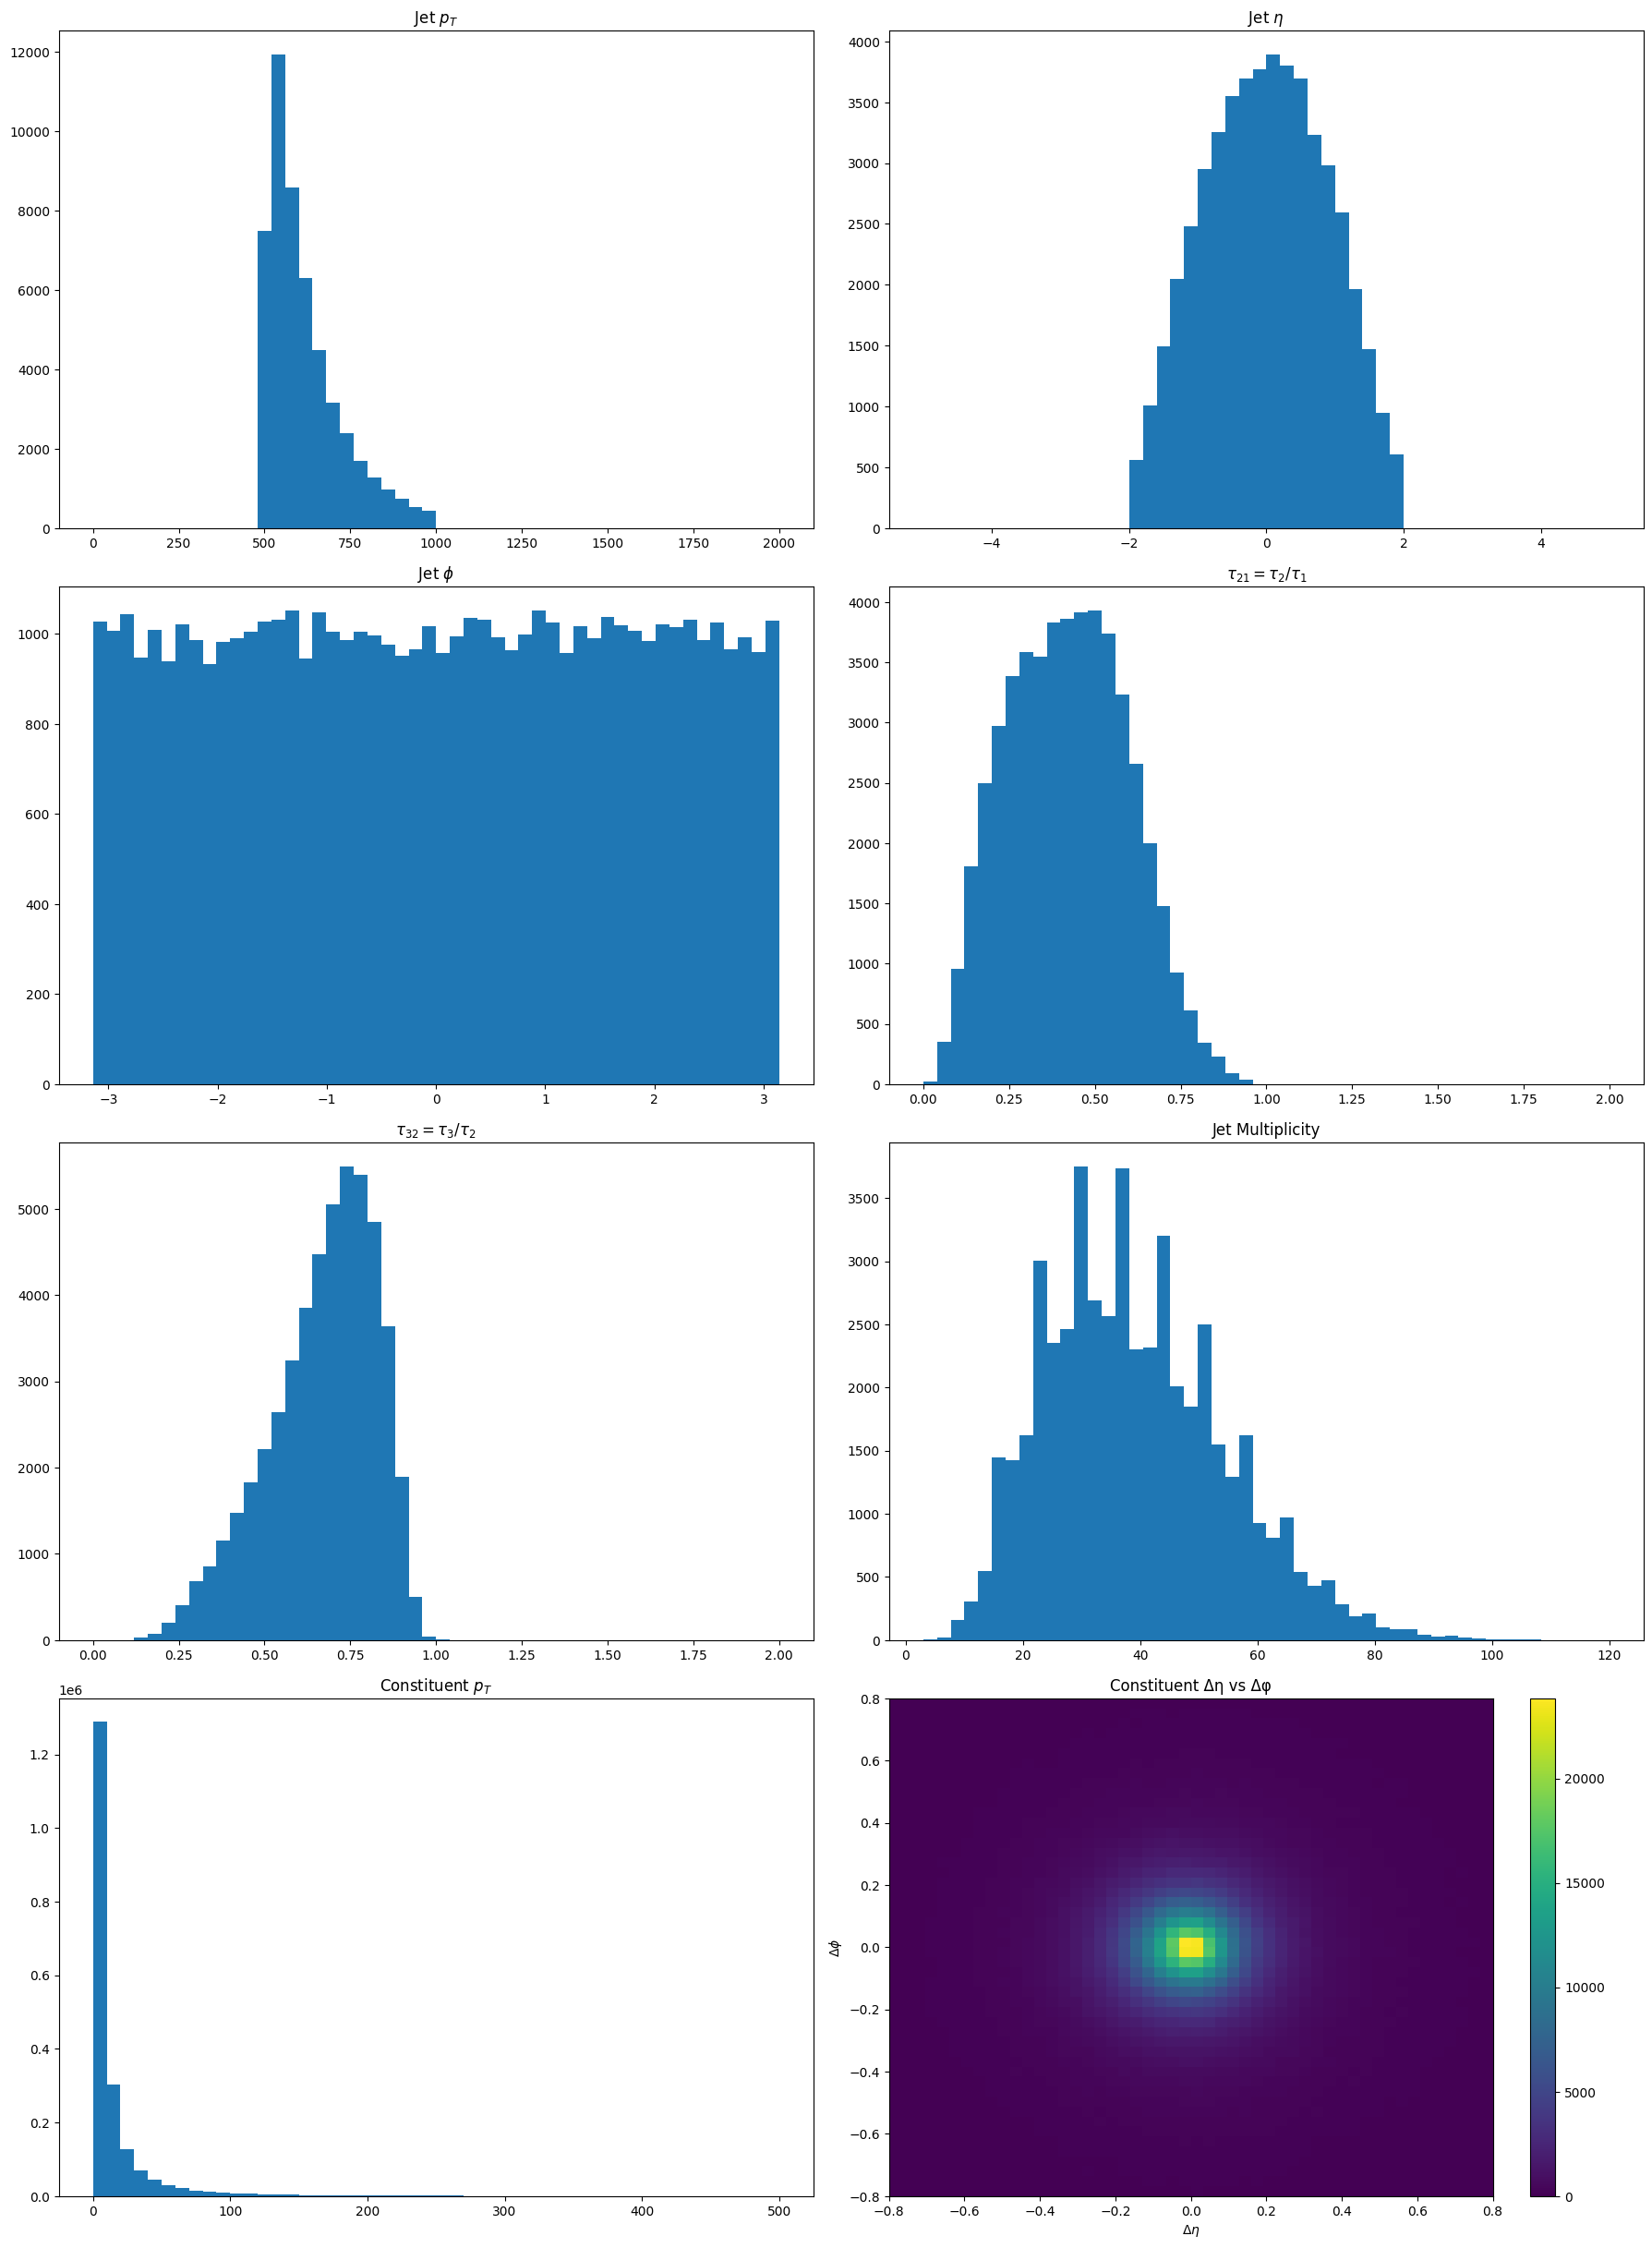

In [33]:
import os
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Directory where your ROOT files are stored
directory_path = "val_5M"

# Accumulators for all variables
jet_pt, jet_eta, jet_phi = [], [], []
tau21, tau32, jet_nparticles = [], [], []
part_px, part_py, part_pz, part_energy = [], [], [], []
part_deta, part_dphi = [], []

# Helper for division
def safe_divide(num, den):
    return np.where(den != 0, num / den, 0)

# Loop through all .root files
for filename in os.listdir(directory_path):
    if filename.endswith(".root"):
        file_path = os.path.join(directory_path, filename)
        try:
            with uproot.open(file_path) as file:
                tree = file["tree"]
                arrays = tree.arrays([
                    "jet_pt", "jet_eta", "jet_phi",
                    "jet_tau1", "jet_tau2", "jet_tau3",
                    "jet_nparticles", "part_px", "part_py", "part_pz", "part_energy",
                    "part_deta", "part_dphi"
                ], entry_stop=1000)

                # Append variables as Awkward Arrays (keep structure)
                jet_pt.append(arrays["jet_pt"])
                jet_eta.append(arrays["jet_eta"])
                jet_phi.append(arrays["jet_phi"])
                tau21.append(safe_divide(arrays["jet_tau2"], arrays["jet_tau1"]))
                tau32.append(safe_divide(arrays["jet_tau3"], arrays["jet_tau2"]))
                jet_nparticles.append(arrays["jet_nparticles"])
                part_px.append(arrays["part_px"])
                part_py.append(arrays["part_py"])
                part_pz.append(arrays["part_pz"])
                part_energy.append(arrays["part_energy"])
                part_deta.append(arrays["part_deta"])
                part_dphi.append(arrays["part_dphi"])

        except Exception as e:
            print(f"Error in {filename}: {e}")

# Concatenate arrays
jet_pt = ak.concatenate(jet_pt)
jet_eta = ak.concatenate(jet_eta)
jet_phi = ak.concatenate(jet_phi)
tau21 = ak.concatenate(tau21)
tau32 = ak.concatenate(tau32)
jet_nparticles = ak.concatenate(jet_nparticles)
part_px = ak.concatenate(part_px)
part_py = ak.concatenate(part_py)
part_pz = ak.concatenate(part_pz)
part_energy = ak.concatenate(part_energy)
part_deta = ak.concatenate(part_deta)
part_dphi = ak.concatenate(part_dphi)

# Compute constituent pt
part_pt = np.sqrt(part_px**2 + part_py**2)

# Compute jet invariant mass from constituent 4-momentum
jet_px = ak.sum(part_px, axis=1)
jet_py = ak.sum(part_py, axis=1)
jet_pz = ak.sum(part_pz, axis=1)
jet_E = ak.sum(part_energy, axis=1)

jet_mass2 = jet_E**2 - (jet_px**2 + jet_py**2 + jet_pz**2)
jet_mass = np.sqrt(ak.to_numpy(ak.where(jet_mass2 > 0, jet_mass2, 0)))

# Plotting
plt.figure(figsize=(18, 30))

# 1. Jet pt
plt.subplot(5, 2, 1)
plt.hist(jet_pt, bins=50, range=(0, 2000))
plt.title("Jet $p_T$")

# 2. Jet eta
plt.subplot(5, 2, 2)
plt.hist(jet_eta, bins=50, range=(-5, 5))
plt.title("Jet $\eta$")

# 3. Jet phi
plt.subplot(5, 2, 3)
plt.hist(jet_phi, bins=50, range=(-np.pi, np.pi))
plt.title("Jet $\phi$")

# 4. tau21
plt.subplot(5, 2, 4)
plt.hist(tau21, bins=50, range=(0, 2))
plt.title(r"$\tau_{21} = \tau_2 / \tau_1$")

# 5. tau32
plt.subplot(5, 2, 5)
plt.hist(tau32, bins=50, range=(0, 2))
plt.title(r"$\tau_{32} = \tau_3 / \tau_2$")

# 6. Multiplicity
plt.subplot(5, 2, 6)
plt.hist(jet_nparticles, bins=50)
plt.title("Jet Multiplicity")

# 7. Constituent pt
plt.subplot(5, 2, 7)
plt.hist(ak.to_numpy(ak.flatten(part_pt)), bins=50, range=(0, 500))

plt.title("Constituent $p_T$")

# 8. Δη vs Δφ
plt.subplot(5, 2, 8)
plt.hist2d(
    ak.to_numpy(ak.flatten(part_deta)),
    ak.to_numpy(ak.flatten(part_dphi)),

    bins=50,
    range=[[-0.8, 0.8], [-0.8, 0.8]],
    cmap="viridis"
)
plt.colorbar()
plt.xlabel(r"$\Delta\eta$")
plt.ylabel(r"$\Delta\phi$")
plt.title("Constituent Δη vs Δφ")

plt.tight_layout()
plt.show()


Number of ROOT files found: 50


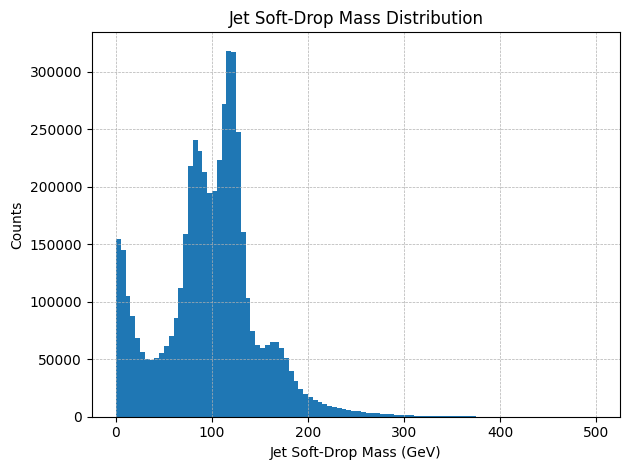

In [34]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import glob

# Find all .root files in the val_5M directory
file_list = glob.glob("val_5M/*.root")
print("Number of ROOT files found:", len(file_list))

all_jet_masses = []

# Extract the 'jet_sdmass' variable from each file
for filename in file_list:
    with uproot.open(filename) as file:
        tree = file["tree"]
        jet_sdmass = tree["jet_sdmass"].array()
        all_jet_masses.append(jet_sdmass)

# Merge all mass arrays into a single array
all_jet_masses = ak.concatenate(all_jet_masses)
mass_array = ak.to_numpy(all_jet_masses)

# Plot histogram with logarithmic Y scale
plt.hist(mass_array, bins=100, range=(0, 500), histtype='stepfilled')
plt.xlabel("Jet Soft-Drop Mass (GeV)")
plt.ylabel("Counts")
plt.title("Jet Soft-Drop Mass Distribution")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()



Number of ROOT files found: 50


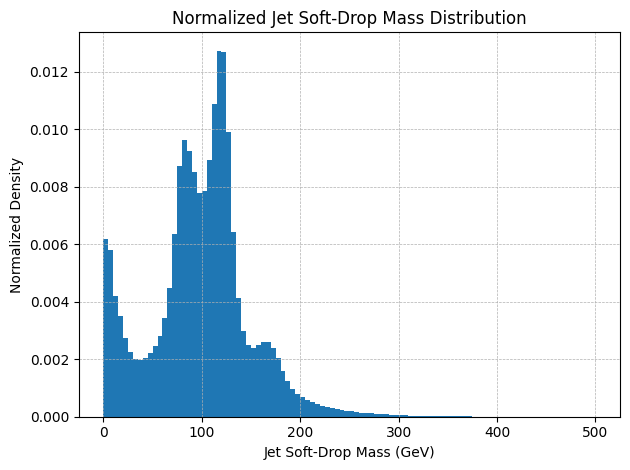

In [35]:
# Find all .root files in the val_5M directory
file_list = glob.glob("val_5M/*.root")
print("Number of ROOT files found:", len(file_list))

all_jet_masses = []

# Extract the 'jet_sdmass' variable from each file
for filename in file_list:
    with uproot.open(filename) as file:
        tree = file["tree"]
        jet_sdmass = tree["jet_sdmass"].array()
        all_jet_masses.append(jet_sdmass)

# Merge all mass arrays into a single array
all_jet_masses = ak.concatenate(all_jet_masses)
mass_array = ak.to_numpy(all_jet_masses)

# Plot normalized histogram with logarithmic Y scale
plt.hist(mass_array, bins=100, range=(0, 500), histtype='stepfilled', density=True)
plt.xlabel("Jet Soft-Drop Mass (GeV)")
plt.ylabel("Normalized Density")
plt.title("Normalized Jet Soft-Drop Mass Distribution")
#plt.yscale("log") 
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


Number of ROOT files found: 50


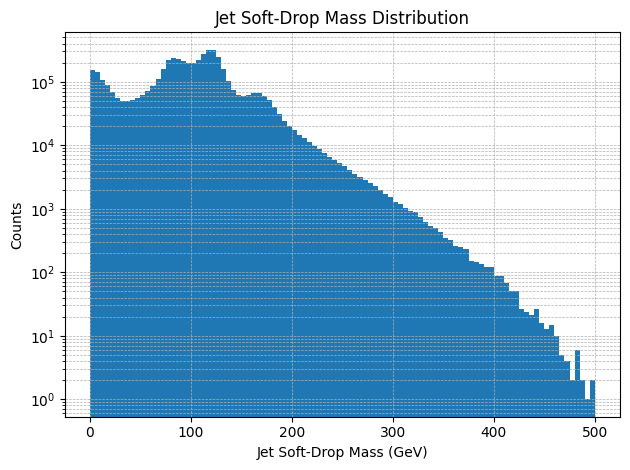

In [36]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import glob

# Find all .root files in the val_5M directory
file_list = glob.glob("val_5M/*.root")
print("Number of ROOT files found:", len(file_list))

all_jet_masses = []

# Extract the 'jet_sdmass' variable from each file
for filename in file_list:
    with uproot.open(filename) as file:
        tree = file["tree"]
        jet_sdmass = tree["jet_sdmass"].array()
        all_jet_masses.append(jet_sdmass)

# Merge all mass arrays into a single array
all_jet_masses = ak.concatenate(all_jet_masses)
mass_array = ak.to_numpy(all_jet_masses)

# Plot histogram with logarithmic Y scale
plt.hist(mass_array, bins=100, range=(0, 500), histtype='stepfilled')
plt.xlabel("Jet Soft-Drop Mass (GeV)")
plt.ylabel("Counts")
plt.title("Jet Soft-Drop Mass Distribution")
plt.yscale("log")  # Apply logarithmic scale to Y-axis
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [37]:
with uproot.open("val_5M/HToBB_120.root") as file:
    tree = file["tree"]
    print(tree.keys())  


['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy', 'jet_nparticles', 'jet_sdmass', 'jet_tau1', 'jet_tau2', 'jet_tau3', 'jet_tau4', 'aux_genpart_eta', 'aux_genpart_phi', 'aux_genpart_pid', 'aux_genpart_pt', 'aux_truth_match']


Number of ROOT files found: 50


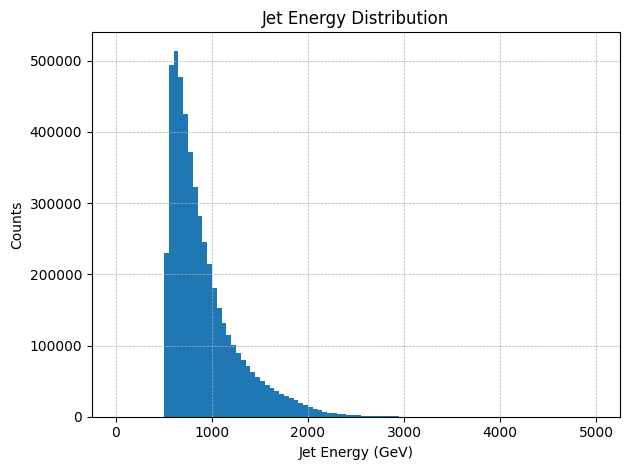

In [38]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import glob

# Find all .root files in the val_5M directory
file_list = glob.glob("val_5M/*.root")
print("Number of ROOT files found:", len(file_list))

all_jet_energies = []

# Extract the 'jet_energy' variable from each file
for filename in file_list:
    with uproot.open(filename) as file:
        tree = file["tree"]
        jet_energy = tree["jet_energy"].array()
        all_jet_energies.append(jet_energy)

# Merge all energy arrays into a single array
all_jet_energies = ak.concatenate(all_jet_energies)
energy_array = ak.to_numpy(all_jet_energies)

# Plot histogram with logarithmic Y scale
plt.hist(energy_array, bins=100, range=(0, 5000), histtype='stepfilled')
plt.xlabel("Jet Energy (GeV)")
plt.ylabel("Counts")
plt.title("Jet Energy Distribution")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


Number of ROOT files found: 50


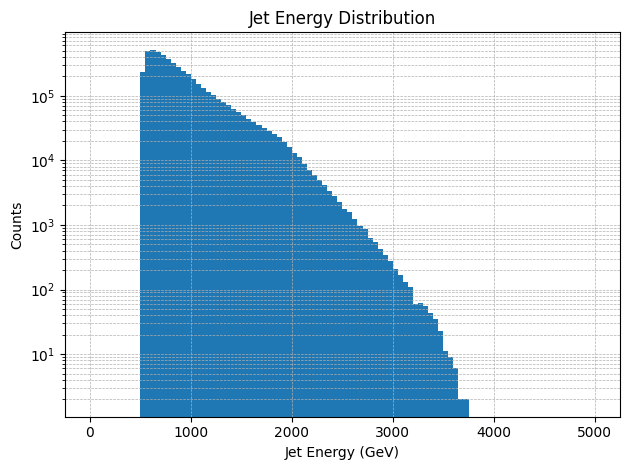

In [39]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import glob

# Find all .root files in the val_5M directory
file_list = glob.glob("val_5M/*.root")
print("Number of ROOT files found:", len(file_list))

all_jet_energies = []

# Extract the 'jet_energy' variable from each file
for filename in file_list:
    with uproot.open(filename) as file:
        tree = file["tree"]
        jet_energy = tree["jet_energy"].array()
        all_jet_energies.append(jet_energy)

# Merge all energy arrays into a single array
all_jet_energies = ak.concatenate(all_jet_energies)
energy_array = ak.to_numpy(all_jet_energies)

# Plot histogram with logarithmic Y scale
plt.hist(energy_array, bins=100, range=(0, 5000), histtype='stepfilled')
plt.xlabel("Jet Energy (GeV)")
plt.ylabel("Counts")
plt.title("Jet Energy Distribution")
plt.yscale("log")  # Logarithmic scale for Y-axis
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
